# Run BEHAV3D feature extraction and T cell analysis

**Expected duration full processing per full time-series BEHAV3D position: ~4-5 hours**

This notebook runs the feature extraction and behavioral analysis pipeline of BEHAV3D

To work correctly, it requires the following input:
- A metadata ***.csv*** containing information on every sample to be processed
- A 5D (tczyx) microscopy image (***.czi/.tiff/.zarr***)

*Optional*: You can supply your own segmentation/tracking in the metadata .csv and skip the segmentation/tracking by BEHAV3D

### Load required packages

In [ ]:
#Load the packages
from behav3d.preprocessing.segmentation.unet_segmentation import run_behav3d_unet_segmentation
from behav3d.preprocessing.segmentation.napari_pixelclassifier import train_pixel_classifier, run_pixel_classifier_segmentation, print_image_shape
from behav3d.preprocessing.segmentation.cellpose_prediction import run_cellpose_prediction,run_cellpose_segmentation,visualize_cellpose_sample,run_otsu_threshold_segmentation_from_zarr

from behav3d.preprocessing.tracking.laptracking import run_tcell_laptracking
from behav3d.preprocessing.tracking.propagation_tracking import run_propagation_tracking
from behav3d.preprocessing.tracking.trackpy_tracking import run_organoid_trackpy_tracking

from behav3d.utils.tracking import convert_all_tracked_images_to_csv

from behav3d.analysis.feature_extraction import run_feature_extraction
from behav3d.analysis.tcell_analysis import filter_tcell_tracks, summarize_track_features, run_tcell_analysis
from behav3d.analysis.organoid_analysis import filter_organoid_tracks, run_organoid_analysis
from behav3d.analysis.backprojection import backproject_mean_features_behav3d

from behav3d.utils import load_behav3d_metadata, check_behav3d_metadata

from behav3d.utils.behav3d_widgets import *
import pandas as pd
from pathlib import Path

import torch
import zarr
import dask.array as da
import tqdm

import ipywidgets as widgets
from IPython.display import display, clear_output

import random
random.seed(42)  # sets the seed for the random module

import numpy as np
np.random.seed(42)  # sets the seed for numpy random functions


%matplotlib inline

### Set BEHAV3D parameters

***NOTE*** 

Dynamic Time Warping seems to work best if all tracks are of equal length. To get tracks to equal length, set both ***tcell_min_track_length*** and ***tcell_max_track_length*** to the same value

**!!! Make sure channel indexing in metadata csv starts at channel 0!!!**

Checks the supplied metadata .csv for:
- Are all required columns filled in?
- Do all the supplied paths per row exist?

In [2]:
# Import metadata
load_button1.on_click(on_load_clicked1)
display(output_dir_widget, metadata_path_widget, load_button1, output_area1)

Text(value='D:/SURF_2/Scripts/Python/BEHAV3D3_0/output', description='Output Dir:', layout=Layout(width='100%'…

Text(value='D:/SURF_2/Scripts/Python/BEHAV3D3_0/metadata.csv', description='Metadata:', layout=Layout(width='1…

Button(button_style='success', description='Load Metadata', style=ButtonStyle())

Output()

---

# Preprocessing of input images for BEHAV3D processing

---
For Pixel classifier training: **Label 1** is background / **Label 2** is foreground. 
### Segment all input images
*Expected duration: ~3.5 hours per image, ~20 seconds per timepoint*,

In [4]:
# Check dimensions order
image_path = metadata.loc[0, "raw_image_path"]

# Call the helper function
print_image_shape(image_path)

Image loaded from: D:/SURF_2/LAB_work/1.Data/BHVD/r06c05f01_timeseries_a.tiff
Shape: (143, 20, 3, 1080, 1080)


(143, 20, 3, 1080, 1080)

In [6]:
# Possible dimension orderings

manual_dim_order_widget.observe(on_dim_order_change, names='value')

# Show the widget
display(manual_dim_order_widget)


Dropdown(description='Select Order:', layout=Layout(width='300px'), options=(('T, C, Z, Y, X', ('T', 'C', 'Z',…

In [3]:
# Choose CellPose models
Cell_poseTcell_widget = widgets.Text(
    value=r"D:/SURF_2/Scripts/Python/BEHAV3D3_0/cellpose/cellpose_TKI_tcells",
    description='T cell CellPose Model Dir:',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='100%')
)

Cell_poseOrg_widget = widgets.Text(
    value=r"D:/SURF_2/Scripts/Python/BEHAV3D3_0/cellpose/cellpose_TKI_organoids",
    description='Org CellPose Model Dir:',
    style={'description_width': '160px'},
    layout=widgets.Layout(width='100%')
)

load_button = widgets.Button(description="Load CellPose Models", button_style='success')
output_area = widgets.Output()

def on_load_clicked(b):
    global pretrained_model_dirTcell, pretrained_model_dirOrg
    pretrained_model_dirTcell = Cell_poseTcell_widget.value
    pretrained_model_dirOrg = Cell_poseOrg_widget.value
    
    with output_area:
        clear_output()
        print(f"✅ Loaded CellPose model paths:")
        print(f"  - T cell model:    {pretrained_model_dirTcell}")
        print(f"  - Organoid model:  {pretrained_model_dirOrg}")

load_button.on_click(on_load_clicked)

# Display both widgets + button + output
display(Cell_poseTcell_widget, Cell_poseOrg_widget, load_button, output_area)


Text(value='D:/SURF_2/Scripts/Python/BEHAV3D3_0/cellpose/cellpose_TKI_tcells', description='T cell CellPose Mo…

Text(value='D:/SURF_2/Scripts/Python/BEHAV3D3_0/cellpose/cellpose_TKI_organoids', description='Org CellPose Mo…

Button(button_style='success', description='Load CellPose Models', style=ButtonStyle())

Output()

In [4]:
# Run T cell segmentation with Cellpose
metadata = run_cellpose_segmentation(
    output_dir          = output_dir,
    metadata            = metadata,
    pretrained_model_dir= pretrained_model_dirTcell,
    timepoint_range     = (0, 2),      # None → all frames
    manual_dim_order    = manual_dim_order,  # e.g. "CTZYX" if the file axes differ
    label_name="tcell" ,    
    overwrite           = False,
)

# Persist the new mask paths back to disk so later stages can use them
metadata.to_csv(metadata_csv_path, index=True)
print("✓ T cell segmentation finished and metadata.csv updated")

Calculating features for: r06c05f01_timeseries_a
(143, 3, 20, 1080, 1080)
✓ T cell segmentation finished and metadata.csv updated


In [5]:
# Run Organoid segmentation with Cellpose
metadata = run_cellpose_segmentation(
    output_dir          = output_dir,
    metadata            = metadata,
    pretrained_model_dir= pretrained_model_dirOrg,
    timepoint_range     = (0, 2),      # None → all frames
    manual_dim_order    = manual_dim_order,  # e.g. "CTZYX" if the file axes differ
    label_name="organoid" ,    
    overwrite           = False,
)

# Persist the new mask paths back to disk so later stages can use them
metadata.to_csv(metadata_csv_path, index=True)
print("✓ Organoid segmentation finished and metadata.csv updated")

Calculating features for: r06c05f01_timeseries_a
(143, 3, 20, 1080, 1080)
✓ Organoid segmentation finished and metadata.csv updated


In [6]:
# Run dead dye segmentation
run_otsu_threshold_segmentation_from_zarr(
    output_dir= output_dir,
    metadata=metadata,
    channel = 2,
    mask_suffix = "_mask_dead",
    timepoint_range= (0, 2), 
    overwrite = False,
)


Processing r06c05f01_timeseries_a...
[INFO] Global Otsu threshold: 862
[SKIP] Mask already exists: D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\images\r06c05f01_timeseries_a\r06c05f01_timeseries_a_mask_dead.zarr


In [11]:
# 👀 3. Visualise one sample interactively in Napari
#    Just change 'sample_name' (must match the column in metadata.csv).
visualize_cellpose_sample(
    output_dir=output_dir,
    sample_name     = "r06c05f01_timeseries_a",   # choose any row
    timepoint_range = (0, 2)                   # optional
)

Sample selected: r06c05f01_timeseries_a
Timepoint range: (0, 2)
Mask 'tcell_segments' path: D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\images\r06c05f01_timeseries_a\r06c05f01_timeseries_a_tcell_segments.zarr
Mask 'organoid_segments' path: D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\images\r06c05f01_timeseries_a\r06c05f01_timeseries_a_organoid_segments.zarr
Mask 'mask_dead' path: D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\images\r06c05f01_timeseries_a\r06c05f01_timeseries_a_mask_dead.zarr
Original image shape: (143, 3, 20, 1080, 1080)
Slicing timepoints from 0 to 2


Adding mask layer 'tcell_segments' to viewer...
Adding mask layer 'organoid_segments' to viewer...
Adding mask layer 'mask_dead' to viewer...
Launching Napari viewer...


### Track all T cells images & Organoid

In [3]:
# Tracking
print("######## Running tracking on Organoids")
metadata = run_organoid_trackpy_tracking(
    metadata = metadata, 
    output_dir=output_dir,
    element_size_x=1,
    element_size_y=1,
    element_size_z=1,
    search_range=10,
    memory=0,
    adaptive_stop=50.0,
    adaptive_step=0.95,
    cell_type="organoid",
    tracking_method='trackpy_post', 
    )
print("\n!!! Overwriting 'organoid_tracks_image_path' and 'organoid_tracks_csv_path' in metadata.csv")
metadata.to_csv(metadata_csv_path, sep=",", index=False)


Frame 2: 513 trajectories present.
Found 769 tracks
Saving tracked image to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\images\r06c05f01_timeseries_a\r06c05f01_timeseries_a_organoid_tracked.zarr
Saving tracks CSV to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\trackdata\r06c05f01_timeseries_a\organoid\r06c05f01_timeseries_a_organoid_tracks.csv

!!! Overwriting 'organoid_tracks_image_path' and 'organoid_tracks_csv_path' in metadata.csv


In [5]:
# Tracking
print("######## Running tracking on Tcells")
metadata = run_organoid_trackpy_tracking(
    metadata = metadata, 
    output_dir=output_dir,
    element_size_x=1,
    element_size_y=1,
    element_size_z=1,
    search_range=10,
    memory=0,
    adaptive_stop=10.0,
    adaptive_step=0.95,
    cell_type="tcell",
    tracking_method='trackpy_post', 
    )
print("\n!!! Overwriting 'tcell_tracks_image_path' and 'tcell_tracks_csv_path' in metadata.csv")
metadata.to_csv(metadata_csv_path, sep=",", index=False)


######## Running tracking on Tcells

Processing r06c05f01_timeseries_a...
Running trackpy_post tracking...


In [8]:
# Tracking
print("######## Running tracking on T-cells")
metadata = run_tcell_laptracking(
    metadata = metadata, 
    output_dir=output_dir,
    overwrite=False,
    cell_type="tcell",
    logger=None
    )
print("\n!!! Overwriting 'tcell_tracks_image_path' and 'tcell_tracks_csv_path' in metadata.csv")
metadata.to_csv(metadata_csv_path, sep=",", index=False)

print("######## Running tracking on organoids")
metadata = run_propagation_tracking(
    metadata = metadata,
    output_dir = output_dir,
    cell_type="organoid",
    overwrite=True,
    )
print("\n!!! Overwriting 'organoid_tracks_csv_path' in metadata.csv")
metadata.to_csv(metadata_csv_path, sep=",", index=False)

######## Running tracking on T-cells
Tracking sample: r06c05f01_timeseries_a
Overwriting the original segments IDs with the tracked IDs


100%|██████████| 3/3 [00:07<00:00,  2.51s/it]



!!! Overwriting 'tcell_tracks_image_path' and 'tcell_tracks_csv_path' in metadata.csv
######## Running tracking on organoids
Tracking sample: r06c05f01_timeseries_a


100%|██████████| 3/3 [00:00<00:00,  3.36it/s]


!!! Overwriting 'organoid_tracks_csv_path' in metadata.csv


---

# Calculate the track features, filter tracks and summarize track features

---

**calculate_track_features** <br>
Calculates movement, contact and intensity features for each timepoint in all tracks per experiment

**filter_tracks** <br>
Filter out tracks based on:
- Maximum experiment length (tcell_exp_duration)    
- Minimum track length (tcell_min_track_length)
- Tracks starting at timepoint 1 with a dead dye mean over the dead_dye_threshold (dead_dye_threshold)

Additonally, all tracks are cut down to:
- Maximum track length (tcell_max_track_length)

**summarize_track_features** <br>
Summarizes the features into one value for each TrackID per experiment

--------------------


## T cells

**Calculation of track features**

*Expected duration: ~30 minutes*

In [14]:
# T cell feature extraction
run_feature_extraction(
    dead_mask_percentage_threshold=0.2,
    metadata=metadata, 
    output_dir=output_dir, 
    cell_type="tcell",
    n_workers=16
    )

--------------- Processing tcell: r06c05f01_timeseries_a ---------------
###### Running track feature calculation
15:49:41 - Converting all input files to .zarr for memory efficiency...
Skipping conversion of tcell segments to zarr, as file already exists
Skipping conversion of organoid segments to zarr, as file already exists
Skipping conversion of raw_image to zarr, as file already exists
15:49:41 - Loading in tracks csv...
15:49:41 - Generalizing the units of position and time to um and hours
15:49:41 - Converting distance and time unit to default um and hours...


KeyError: 'TrackID'

In [12]:
display(metadata)

,sample_name,organoid_line,tcell_line,exp_nr,well,tcell_channel,live_channel,dead_channel,contact_threshold,pixel_distance_xy,...,distance_unit,time_interval,time_unit,raw_image_path,tcell_segments_image_path,tcell_tracks_image_path,tcell_tracks_csv_path,organoid_segments_image_path,organoid_tracks_image_path,organoid_tracks_csv_path
0,r06c05f01_timeseries_a,169M,MAGE-A4 TCB,1,well0,0,1,2,3.6,1.77,...,μm,1200.0,s,D:/SURF_2/LAB_work/1.Data/BHVD/r06c05f01_times...,D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI...,NaN,NaN,D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI...,D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI...,D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI...


## Organoids

In [4]:
# Organoid feature extraction
run_feature_extraction(
    metadata=metadata, 
    output_dir=output_dir, 
    cell_type="organoid",
    n_workers=16
    )

--------------- Processing organoid: r06c05f01_timeseries_a ---------------
###### Running track feature calculation
16:25:21 - Converting all input files to .zarr for memory efficiency...
Skipping conversion of tcell segments to zarr, as file already exists
Skipping conversion of organoid segments to zarr, as file already exists
Skipping conversion of raw_image to zarr, as file already exists
16:25:21 - Loading in tracks csv...
16:25:21 - Generalizing the units of position and time to um and hours
16:25:21 - Converting distance and time unit to default um and hours...


D:\SURF_2\Scripts\Python\BEHAV3D3_0\behav3dMA\behav3d\analysis\feature_extraction.py:540: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_tracks = df_tracks.groupby('TrackID').apply(calculate_relative_time).reset_index(drop=True)


16:25:21 - Calculating single-timepoint image-based features...
16:25:21 - Calculating morphology features...


100%|██████████| 3/3 [00:03<00:00,  1.00s/it]


16:25:25 - Calculating channel and especially death dye intensities...


100%|██████████| 3/3 [00:01<00:00,  1.95it/s]


16:25:26 - Calculating number of dead mask pixels...


100%|██████████| 3/3 [00:00<00:00,  9.73it/s]
D:\SURF_2\Scripts\Python\BEHAV3D3_0\behav3dMA\behav3d\analysis\feature_extraction.py:1095: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  result = df.groupby(groupby).apply(compute_increase)


ValueError: Cannot remove 1 levels from an index with 1 levels: at least one level must be left.

---

# Perform data analysis

---

## T cell behavioral analysis

**Filtering tracks and summarizing features**

*Expected duration: <1 minute*

### Filtering Parameters 

- **exp_duration**  
  Maximum length of the experiment in timepoints.  
  All data points after this timepoint will be excluded.  
  *Use this to remove late timepoints where imaging quality may degrade significantly.*

- **tcell_min_track_length**  
  Minimum track length to include in the analysis.  
  *Tracks shorter than this are filtered out, typically removing segmentation or tracking errors.*

- **tcell_max_track_length**  
  Maximum track length to include in the analysis.  
  *Longer tracks will be truncated to this length to ensure comparability across tracks of equal length.*


In [11]:
# Select
set_params_button.on_click(on_set_params_clicked)

display(exp_duration_widget)
display(min_track_length_widget, max_track_length_widget)
display(set_params_button, output_area_params)


IntText(value=1000, description='Exp Duration:', layout=Layout(width='300px'), style=DescriptionStyle(descript…

IntSlider(value=100, description='Min Track Length:', layout=Layout(width='300px'), max=1000, style=SliderStyl…

IntSlider(value=500, description='Max Track Length:', layout=Layout(width='300px'), max=1000, style=SliderStyl…

Button(button_style='info', description='Set Parameters', style=ButtonStyle())

Output()

In [12]:
# Filter T cell tracks
df_tracks_filt = filter_tcell_tracks(
    metadata=metadata, 
    output_dir=output_dir, 
    exp_duration=exp_duration,
    min_track_length=tcell_min_track_length,
    max_track_length=tcell_max_track_length,
    filter_t0_dead=True,
    cell_type="tcell"
    )
df_tracks_summ = summarize_track_features(
    output_dir=output_dir,
    cell_type="tcell")

--------------- Filtering tracks ---------------
- Plotting tcell touching distribution to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\quality_control\BEHAV3D_tcell_touching_distribution.pdf


D:\SURF_2\Scripts\Python\BEHAV3D3_0\behav3dMA\behav3d\analysis\tcell_analysis.py:204: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_all_tracks_filt=df_all_tracks_filt.groupby(group_cols).apply(lambda group: group.iloc[:max_track_length]).reset_index(drop=True)


- Plotting organoid touching distribution to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\quality_control\BEHAV3D_organoid_touching_distribution.pdf
- Plotting dead dye distribution at all timepoints to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\quality_control\BEHAV3D_dead_dye_distribution.pdf
- Plotting dead dye distribution at timepoint 1 to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\quality_control\BEHAV3D_dead_dye_distribution.pdf
- Plotting track counts after filtering steps to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\quality_control\BEHAV3D_filter_counts.pdf
- Writing filtered tracks to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\track_features\BEHAV3D_tcell_combined_track_features_filtered.csv
### DONE - elapsed time: 0:00:01

--------------- Summarizing track features ---------------
- Writing summarized tracks to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\track_fea

D:\SURF_2\Scripts\Python\BEHAV3D3_0\behav3dMA\behav3d\utils\analysis.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
D:\SURF_2\Scripts\Python\BEHAV3D3_0\behav3dMA\behav3d\analysis\tcell_analysis.py:343: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  df_summarized_tracks['active_tcell_contact'] = grouped_df_tracks.apply(calculate_active_contact_when_contact).reset_index(drop=True)


***Dynamic Time Warping*** <br>

Performs Dynamic Time Warping on the various tracks using various features to calculate a distance matrix between all tracks

Select the features to use for analysis

Features used for dynamic time warping by default:
- z_mean_square_displacement
- z_speed
- z_mean_dead_dye
- tcell_contact
- organoid_contact



*Expected duration: ~1 minute*


In [13]:
# Select
save_button2.on_click(on_save_clicked)
display(widgets.Label("Select features to use for Dynamic Time Warping (DTW):"))
display(checkboxes_box)
display(save_button2)
display(output_area2)


Label(value='Select features to use for Dynamic Time Warping (DTW):')

Button(button_style='success', description='Save DTW Features', layout=Layout(width='200px'), style=ButtonStyl…

Output()

***UMAP fitting and clustering*** <br>

This distance matrix is fitted into a UMAP, and K-means clustering is used to cluster the tracks into clusters

Parameters for UMAP and clustering can be adjusted:
- umap_minimal_distance
- umap_n_neighbors
- nr_of_clusters

***Cluster features display*** <br>

The results of the clustering are displayed in multiple ways:
- The UMAP with clusters and features backprojected onto this UMAP (BEHAV3D_UMAP_clusters.csv)
- A heatmap containing the mean feature values for all tracks per cluster to check general behavior patterns (BEHAV3D_UMAP_cluster_feature_heatmap.pdf)
- A barplot containing the percentages of cells belonging to each cluster per Tcell type (rows) and organoid lines (columns)

In [14]:
# Select

save_button3.on_click(on_save_clicked3)

display(umap_distance_widget, umap_neighbors_widget, num_clusters_widget)
display(save_button3, output_area3)

FloatSlider(value=0.1, description='UMAP dist:', max=1.0, step=0.05, style=SliderStyle(description_width='64px…

IntSlider(value=5, description='UMAP neighbors:', max=50, min=2, style=SliderStyle(description_width='101px'))

IntSlider(value=6, description='Num Clusters:', max=20, min=2, style=SliderStyle(description_width='80px'))

Button(button_style='success', description='UMAP&Clustering Params', layout=Layout(width='250px'), style=Butto…

Output()

In [15]:
# Run behavioral clustering
random.seed(42)  # sets the seed for the random module
df_tracks_clustered = run_tcell_analysis(
    output_dir=output_dir,
    umap_minimal_distance=umap_minimal_distance,
    umap_n_neighbors=umap_n_neighbors,
    nr_of_clusters=nr_of_clusters,
    dtw_features= dtw_features
    )

--------------- Performing T-cell behavioral analysis ---------------
- Calculating the dynamic time warping distance matrix
- Fitting the dynamic time warping to a UMAP


c:\Users\akrashen\Miniforge3\envs\behav3dma\Lib\site-packages\umap\umap_.py:1865: UserWarning: using precomputed metric; inverse_transform will be unavailable
  warn("using precomputed metric; inverse_transform will be unavailable")
c:\Users\akrashen\Miniforge3\envs\behav3dma\Lib\site-packages\umap\umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


- Performing clustering on the UMAP data
- Writing clustered tracks to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\results\BEHAV3D_tcell_UMAP_clusters.csv
- Plotting clustered UMAP plots with displayed Track features to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\results\BEHAV3D_tcell_UMAP_clusters.pdf
- Plotting heatmaps with summarized cluster features to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\results\BEHAV3D_tcell_UMAP_cluster_feature_heatmap.pdf


D:\SURF_2\Scripts\Python\BEHAV3D3_0\behav3dMA\behav3d\analysis\tcell_analysis.py:923: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  cluster_means = df_umap[list(info_cols)+["ClusterID"]].drop(columns=sample_cols).groupby('ClusterID').mean().reset_index()


- Plotting percentage plots of each cluster per combination of T-cell and organoid line to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\results\BEHAV3D_tcell_UMAP_cluster_percentages.pdf
MAGE-A4 TCB
- Writing summarized tracks to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\results\BEHAV3D_tcell_UMAP_cluster_percentages.csv
- Writing summarized tracks to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\tcell\results\BEHAV3D_tcell_UMAP_cluster_percentages.csv
### DONE - elapsed time: 0:00:13



D:\SURF_2\Scripts\Python\BEHAV3D3_0\behav3dMA\behav3d\analysis\tcell_analysis.py:692: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df_clust_perc = df_umap.groupby(["organoid_line", "tcell_line", "ClusterID"]).size().reset_index(name='count')


## Organoid behavioral analysis

**Filtering tracks**

*Expected duration: ~1 minute*


In [16]:
# Filter organoid
df_tracks_filt = filter_organoid_tracks(
    metadata=metadata, 
    output_dir=output_dir, 
    exp_duration=exp_duration,
    min_size = 1000,
    cell_type="organoid"
    )

--------------- Filtering tracks ---------------
- Plotting track counts after filtering steps to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\organoid\quality_control\BEHAV3D_filter_counts.pdf
- Writing filtered tracks to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\organoid\track_features\BEHAV3D_organoid_combined_track_features_filtered.csv
### DONE - elapsed time: 0:00:00



D:\SURF_2\Scripts\Python\BEHAV3D3_0\behav3dMA\behav3d\utils\analysis.py:79: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')


***Death Dynamics*** <br>

--------------- Performing T-cell behavioral analysis ---------------


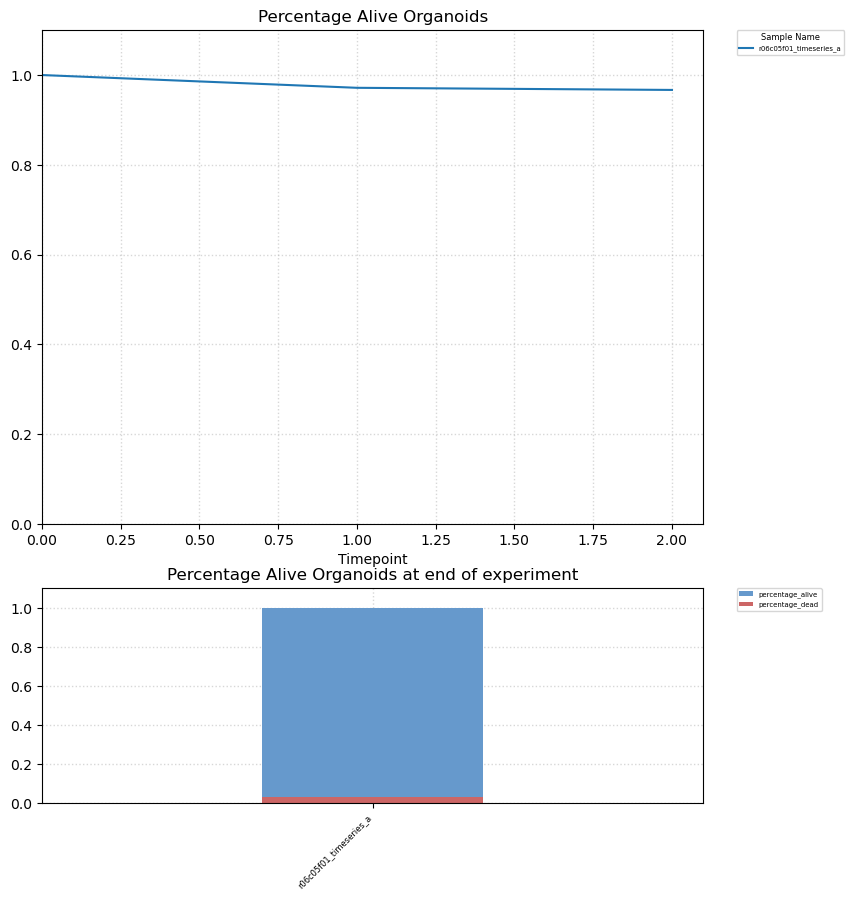

- Writing analysis pdf to D:\SURF_2\Scripts\Python\BEHAV3D3_0\output_TKI\analysis\organoid\results\per_sample\r06c05f01_timeseries_a\organoid\r06c05f01_timeseries_a_organoid_analysis.pdf
### DONE - elapsed time: 0:00:06



In [17]:
# Run Organoid death analysis
df_tracks_clustered = run_organoid_analysis(
    output_dir=output_dir,
    dead_perc_threshold=0.0000001
    )

---

# Backproject results

---

**Visualize the cluster IDs and other features over the segments**
 <br>
 
*Duration: <15 minutes*


In [18]:
# Assuming you have metadata loaded
setup_sample_selection_widgets(metadata)
display(widgets.HBox([sample_dropdown, select_button4]))
display(sample_output)

Output()

In [19]:
# Backproject
backprojection_data = backproject_mean_features_behav3d(
    sample_name=sample_to_backproject,
    metadata=metadata,
    output_dir=output_dir,
    save=False
)

--------------- Backprojecting for r06c05f01_timeseries_a ---------------
- Loading in tracked segments
- Backprojecting all features onto each segment


100%|██████████| 12/12 [00:12<00:00,  1.06s/it]


- Visualizing backprojection in napari


### DONE - elapsed time: 0:00:51



c:\Users\akrashen\Miniforge3\envs\behav3dma\Lib\site-packages\napari\layers\tracks\tracks.py:652: UserWarning: Previous color_by key 'ClusterID' not present in features. Falling back to track_id
  warn(
